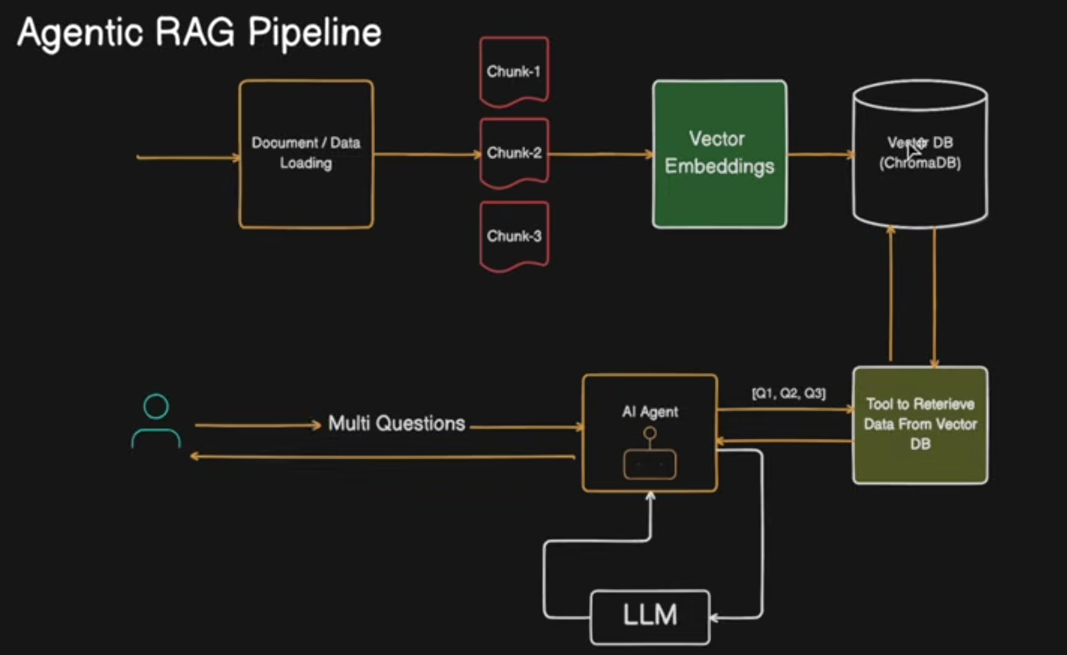

In [54]:
from dotenv import load_dotenv
load_dotenv()

True

In [55]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_google_genai import GoogleGenerativeAIEmbeddings , ChatGoogleGenerativeAI
from langchain_community.vectorstores import InMemoryVectorStore
from langchain.tools import tool
from langchain.agents import create_agent

In [56]:
loader = PyPDFLoader("../data/medical_report.pdf")
docs = loader.load()

In [57]:
len(docs)

9

In [58]:
splitter = RecursiveCharacterTextSplitter(chunk_size = 1000, chunk_overlap = 200)
splitted_docs = splitter.split_documents(docs)

In [59]:
len(splitted_docs)

26

In [60]:
embeddings = GoogleGenerativeAIEmbeddings(model = "gemini-embedding-2")
vector_store = InMemoryVectorStore.from_documents(
    documents = splitted_docs,
    embedding= embeddings
)

### agent = tools, llm , prompt

In [88]:

@tool
def retriever_tool(query:str): 
    """
      This tool can help you to retrieve the relevant data of the PDF Documents, and these PDF documents have details about medical reports.
    """

    print("Tool called : ", query)
    docs = vector_store.similarity_search(query= query, k = 4)
    context = ""

    for doc in docs:
        context = doc.page_content +"\n\n"

    return context 

In [89]:
llm = ChatGoogleGenerativeAI(model = 'gemini-2.5-flash')

In [90]:
System_Prompt = """
You are a helpful assistant.
Use only the retrieved context.
Return only the doctor name(s).
Do not include any extra explanation, metadata, or other fields.
"""

In [91]:
agent = create_agent(
    model = llm,
    tools = [retriever_tool],
    system_prompt= System_Prompt
)

In [92]:
query = "Extract only the patient name and the doctor name from the report."
response = agent.invoke({"messages" : [{"role": "user", "content" : query}]})

Tool called :  patient name and the doctor name from the report


In [93]:
result = response["messages"][-1].content

In [94]:
print(result)

[{'type': 'text', 'text': 'DR NITIN NAHAR, Dr.Swapnil Gupta, Dr Kiran Bhargava Pathak', 'extras': {'signature': 'CtMCARFNMg8nO4gKyylkm42T0eXk3fgf3TBTcKrPclgayMw3iQURHz0+a+3kdLy/mOGi8Eir2CiqDeHWQiLHSASuKhPMKozwb7dTJo5Zl0WhvZuAzypx45yaJXOnZl7f6JOp5+Cc/sDKL0Be547sfo1oHEChrhN0ySAgzTyBGrb43GGxXf9nI/gK9zPyfOXheUKpsDfBJ54g1y03mP9nnQjsWT4GmjvmMImd2wEk8ULHTS4R912hwQFkd3aJx0BOcVBUsSobTjCL1UjGcaFsACCs2T9rPWcFJe/+SwIBRD0vFtHvjxmN+nc9sqkhnY4gW+3bKrF5Qn6cOdCHv62NE5QWbJ+5kNp5gwxfKzb6F9SAYOUkRh/O+kZmvPVaShx+nOvXDelS2FbegGIP+vqVAUfqmvQQwDnfXTRLKsYEDJoK8z/d0CTRgV3xzPvXoW4N3e+HVXwp'}}]
